# Surface Code Tutorial: Stage 1, Stage 2, and AWS PCS

This notebook demonstrates the surface-code workflow. It covers:

1. Motivation: from Shor code to **surface code**.
2. d=3 rotated surface-code structure with Stim and PyMatching.
3. Physical error injection, detector events, and decoding.
4. Stage 2 scale-up to d=5 or larger.
5. AWS PCS workflows that were actually run: `d5_test`, `scaleup_minimal`, and `threshold_sweep`.


## Introduction: Shor Code to Surface Code

Shor code is an excellent conceptual starting point. It shows how bit-flip protection and phase-flip protection can be combined to protect one logical qubit.

However, Shor code is less convenient as a scalable hardware architecture. Its encoding and syndrome-extraction circuits can require nonlocal interactions or long-range CNOT routing. On real hardware, long-range CNOTs are expensive: they may require SWAP networks, deeper circuits, and therefore more noise.

Surface code is designed for scalable hardware:

```text
local / nearest-neighbor interactions
one ancilla interacts only with nearby data qubits
stabilizer measurements repeat in parallel
code distance d can be increased systematically
```

Learning path:

```text
Shor code        -> understand the core idea of quantum error correction
Surface code     -> scalable fault-tolerant architecture with local gates
Stim/PyMatching  -> fast simulation and decoding
AWS PCS          -> large Monte Carlo sweeps with Slurm job arrays
```


# Stage 1: Basic Set Up

## 0. Environment and Glossary

Important terms in ```stim```:

- `distance`: code distance d. Rotated surface code has `d^2` data qubits and `d^2 - 1` ancilla qubits.
- `round`: one syndrome-extraction cycle.
- `physical error`: noise on data qubits, ancillas, gates, reset, or measurement.
- `logical error`: decoder failure that flips a logical observable.
- `syndrome`: stabilizer measurement result.
- `detector_event`: change in syndrome between neighboring QEC rounds.
- `detectors`: number of Stim detector checks.
- `observable`: logical quantity tracked by Stim.
- `observable_flips`: ground-truth logical flips sampled by Stim.
- `logical_errors`: number of shots where decoder prediction differs from `observable_flips`.


In [1]:
from __future__ import annotations
from dataclasses import dataclass

import numpy as np
import pymatching
import stim

print("stim", stim.__version__)
print("pymatching", pymatching.__version__)
print("numpy", np.__version__)


stim 1.16.0
pymatching 2.4.0
numpy 2.4.6


## 1. d=3 Rotated Surface-Code Structure
### 1.1 Main function of rotated rurface-Code

For **rotated surface code**:

```text
data qubits = d^2
ancilla qubits = d^2 - 1
active physical qubits = 2d^2 - 1
```

For d=3:

```text
data = 9
ancilla = 8
active physical qubits = 17
```

```stim``` uses sparse qubit labels. For d=3, the active qubits are 17, but the largest label is 25, so `circuit.num_qubits = 26`. This is a label span, not the number of physical qubits. The main used function is ```build_circuit```.


In [2]:
@dataclass(frozen=True)
class SurfaceCodeSummary:
    distance: int
    rounds: int
    qubit_coords: dict[int, tuple[int, int]]
    data_qubits: list[int]
    ancilla_qubits: list[int]
    num_detectors: int
    num_observables: int
    stim_label_span: int


def build_circuit(distance: int = 3, rounds: int | None = None, p: float = 0.005) -> stim.Circuit:
    if rounds is None:
        rounds = distance
    return stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        distance=distance,
        rounds=rounds,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )


def summarize_circuit(circuit: stim.Circuit, distance: int, rounds: int) -> SurfaceCodeSummary:
    coords = circuit.get_final_qubit_coordinates()
    qubit_coords = {q: (int(xy[0]), int(xy[1])) for q, xy in coords.items()}
    data_qubits, ancilla_qubits = [], []
    for q, (x, y) in sorted(qubit_coords.items()):
        if x % 2 == 1 and y % 2 == 1:
            data_qubits.append(q)
        else:
            ancilla_qubits.append(q)
    return SurfaceCodeSummary(distance, rounds, qubit_coords, data_qubits, ancilla_qubits,
                              circuit.num_detectors, circuit.num_observables, circuit.num_qubits)


def print_coordinate_grid(summary: SurfaceCodeSummary) -> None:
    data_set = set(summary.data_qubits)
    by_coord = {xy: q for q, xy in summary.qubit_coords.items()}
    max_x = max(x for x, _ in by_coord)
    max_y = max(y for _, y in by_coord)
    cell_width = max(len(f"A{q}") for q in summary.qubit_coords) + 1
    print("Coordinate grid: D=data, A=ancilla/stabilizer measurement")
    print("        " + " ".join(f"x={x}".rjust(cell_width) for x in range(max_x + 1)))
    for y in range(max_y + 1):
        cells = []
        for x in range(max_x + 1):
            q = by_coord.get((x, y))
            cells.append(("." if q is None else f"{'D' if q in data_set else 'A'}{q}").rjust(cell_width))
        print(f"y={y}: " + " ".join(cells))


In [3]:
circuit = build_circuit(distance=3, rounds=3, p=0.005)
summary = summarize_circuit(circuit, distance=3, rounds=3)
print(f"data qubits           : {len(summary.data_qubits)} {summary.data_qubits}")
print(f"ancilla/stab qubits   : {len(summary.ancilla_qubits)} {summary.ancilla_qubits}")
print(f"active physical qubits: {len(summary.data_qubits) + len(summary.ancilla_qubits)}")
print(f"Stim qubit label span : {summary.stim_label_span}")
print(f"detectors             : {summary.num_detectors}")
print(f"logical observables   : {summary.num_observables}")
print_coordinate_grid(summary)


data qubits           : 9 [1, 3, 5, 8, 10, 12, 15, 17, 19]
ancilla/stab qubits   : 8 [2, 9, 11, 13, 14, 16, 18, 25]
active physical qubits: 17
Stim qubit label span : 26
detectors             : 24
logical observables   : 1
Coordinate grid: D=data, A=ancilla/stabilizer measurement
         x=0  x=1  x=2  x=3  x=4  x=5  x=6
y=0:    .    .   A2    .    .    .    .
y=1:    .   D1    .   D3    .   D5    .
y=2:    .    .   A9    .  A11    .  A13
y=3:    .   D8    .  D10    .  D12    .
y=4:  A14    .  A16    .  A18    .    .
y=5:    .  D15    .  D17    .  D19    .
y=6:    .    .    .    .  A25    .    .


### 1.2 Stabilizer Circuits

A stabilizer is not directly connected to another stabilizer. Each ancilla/stabilizer qubit connects to nearby data qubits using CNOTs.

Z-stabilizers detect X / bit-flip errors. X-stabilizers detect Z / phase-flip errors.


In [4]:
Z_STABILIZERS = {"Z9": [1, 3, 8, 10], "Z13": [5, 12], "Z14": [8, 15], "Z18": [10, 12, 17, 19]}
X_STABILIZERS = {"X2": [1, 3], "X11": [3, 5, 10, 12], "X16": [8, 10, 15, 17], "X25": [17, 19]}

print("Z stabilizer checks")
for stab, data in Z_STABILIZERS.items():
    print(f"{stab:4s} checks " + ", ".join(f"D{q}" for q in data))
print("\nX stabilizer checks")
for stab, data in X_STABILIZERS.items():
    print(f"{stab:4s} checks " + ", ".join(f"D{q}" for q in data))


Z stabilizer checks
Z9   checks D1, D3, D8, D10
Z13  checks D5, D12
Z14  checks D8, D15
Z18  checks D10, D12, D17, D19

X stabilizer checks
X2   checks D1, D3
X11  checks D3, D5, D10, D12
X16  checks D8, D10, D15, D17
X25  checks D17, D19


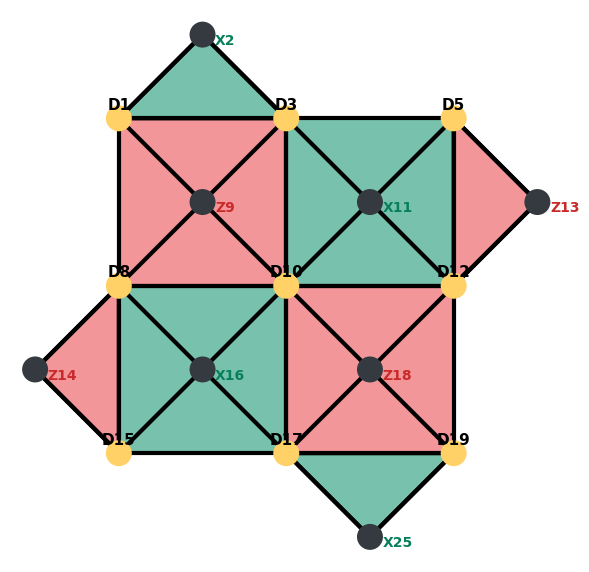

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# Define coordinates (x, y) for data qubits
data_qubits = {
    1: (1, 1), 3: (3, 1), 5: (5, 1),
    8: (1, 3), 10: (3, 3), 12: (5, 3),
    15: (1, 5), 17: (3, 5), 19: (5, 5)
}

# Define coordinates (x, y) for ancilla qubits
z_ancillas = {
    9: (2, 2), 13: (6, 2),
    14: (0, 4), 18: (4, 4)
}

x_ancillas = {
    2: (2, 0),
    11: (4, 2),
    16: (2, 4),
    25: (4, 6)
}

# Define stabilizer checks: which data qubits each ancilla connects to
z_checks = {
    9: [1, 3, 10, 8],
    13: [5, 12],
    14: [8, 15],
    18: [10, 12, 19, 17]
}

x_checks = {
    2: [1, 3],
    11: [3, 5, 12, 10],
    16: [8, 10, 17, 15],
    25: [17, 19]
}

# ---------------------------------------------------------
#  Set up the figure and colors
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
color_X = '#78C2AD'       # X stabilizers, (Mint Green)
color_Z = '#F3969A'       # Z stabilizers, (Coral Pink)
color_data = '#FFD166'    # Data qubits, (Warm Yellow)
color_ancilla = '#343A40' # Ancilla qubits, (Slate Gray)
# ---------------------------------------------------------

def draw_stabilizer(ax, ancilla_id, ancilla_dict, checks_dict, data_dict, facecolor):
    """Draw the polygon patch and internal connection lines for one stabilizer."""
    cx, cy = ancilla_dict[ancilla_id]
    connected_data_ids = checks_dict[ancilla_id]
    points = [data_dict[d_id] for d_id in connected_data_ids]
    
    # Decide whether this stabilizer is a boundary triangle or an interior polygon
    if len(points) == 2:
        poly_points = [points[0], (cx, cy), points[1]]
    else:
        poly_points = sorted(points, key=lambda p: np.arctan2(p[1] - cy, p[0] - cx))
        
    # 1. Draw the filled stabilizer patch
    poly = Polygon(poly_points, closed=True, facecolor=facecolor, edgecolor='none', zorder=1)
    ax.add_patch(poly)
    
    # 2. Draw the thick black outline
    poly_outline = Polygon(poly_points, closed=True, facecolor='none', edgecolor='black', lw=3, zorder=2)
    ax.add_patch(poly_outline)
    
    # 3. Draw internal connection lines from the ancilla to its data qubits
    for p in points:
        ax.plot([cx, p[0]], [cy, p[1]], color='black', lw=3, zorder=2)

# Draw all Z and X stabilizer checks
for z_id in z_checks:
    draw_stabilizer(ax, z_id, z_ancillas, z_checks, data_qubits, color_Z)

for x_id in x_checks:
    draw_stabilizer(ax, x_id, x_ancillas, x_checks, data_qubits, color_X)

# Draw qubit nodes
# Data qubits
dx = [pos[0] for pos in data_qubits.values()]
dy = [pos[1] for pos in data_qubits.values()]
ax.scatter(dx, dy, s=350, c=color_data, edgecolors='none', zorder=3, label='Data')

# Ancilla qubits
ax_coords = [pos[0] for pos in list(z_ancillas.values()) + list(x_ancillas.values())]
ay_coords = [pos[1] for pos in list(z_ancillas.values()) + list(x_ancillas.values())]
ax.scatter(ax_coords, ay_coords, s=350, c=color_ancilla, edgecolors='none', zorder=3, label='Ancilla')

# Add labels, slightly offset from nodes to keep the layout readable
for d_id, (x, y) in data_qubits.items():
    ax.text(x, y - 0.25, f'D{d_id}', ha='center', va='top', fontsize=11, fontweight='bold')

# ---------------------------------------------------------
for a_id, (x, y) in z_ancillas.items():
    ax.text(x + 0.15, y + 0.15, f'Z{a_id}', ha='left', va='bottom', fontsize=10, color='#C92A2A', fontweight='bold') # 深紅色配合Z
for a_id, (x, y) in x_ancillas.items():
    ax.text(x + 0.15, y + 0.15, f'X{a_id}', ha='left', va='bottom', fontsize=10, color='#087F5B', fontweight='bold') # 深綠色配合X
# ---------------------------------------------------------

# Configure the canvas
ax.set_aspect('equal')
ax.invert_yaxis()  # Flip the y-axis so y=0 appears at the top, matching the text-grid convention
ax.axis('off')     # Hide coordinate axes
plt.tight_layout()
plt.show()

In [5]:
def draw_stabilizer_circuit(stabilizer: str, kind: str, data_qubits: list[int]) -> str:
    n = len(data_qubits)
    start = "|0>" if kind == "Z" else "|+>"
    measure = "MZ" if kind == "Z" else "MX"
    def row(label, init, marks, end=""):
        return f"{label:<7}: {init:<4}" + "".join(f"--{m:^5}" for m in marks) + f"-- {end}"
    if kind == "Z":
        lines = [f"{stabilizer} = " + " ".join(f"Z{q}" for q in data_qubits),
                 "legend: o = CNOT control, [X] = CNOT target"]
        lines.append(row(f"A{stabilizer[1:]}", start, ["[X]"] * n, measure))
        for i, q in enumerate(data_qubits):
            lines.append(row(f"D{q}", "", ["o" if j == i else "" for j in range(n)]))
    else:
        lines = [f"{stabilizer} = " + " ".join(f"X{q}" for q in data_qubits),
                 "legend: o = CNOT control, [X] = CNOT target"]
        lines.append(row(f"A{stabilizer[1:]}", start, ["o"] * n, measure))
        for i, q in enumerate(data_qubits):
            lines.append(row(f"D{q}", "", ["[X]" if j == i else "" for j in range(n)]))
        lines.append("equivalent basis change: |0> -- H -- CNOTs -- H -- MZ")
    return "\n".join(lines)

for stab, data in Z_STABILIZERS.items():
    print(draw_stabilizer_circuit(stab, "Z", data), "\n")
for stab, data in X_STABILIZERS.items():
    print(draw_stabilizer_circuit(stab, "X", data), "\n")


Z9 = Z1 Z3 Z8 Z10
legend: o = CNOT control, [X] = CNOT target
A9     : |0> -- [X] -- [X] -- [X] -- [X] -- MZ
D1     :     --  o  --     --     --     -- 
D3     :     --     --  o  --     --     -- 
D8     :     --     --     --  o  --     -- 
D10    :     --     --     --     --  o  --  

Z13 = Z5 Z12
legend: o = CNOT control, [X] = CNOT target
A13    : |0> -- [X] -- [X] -- MZ
D5     :     --  o  --     -- 
D12    :     --     --  o  --  

Z14 = Z8 Z15
legend: o = CNOT control, [X] = CNOT target
A14    : |0> -- [X] -- [X] -- MZ
D8     :     --  o  --     -- 
D15    :     --     --  o  --  

Z18 = Z10 Z12 Z17 Z19
legend: o = CNOT control, [X] = CNOT target
A18    : |0> -- [X] -- [X] -- [X] -- [X] -- MZ
D10    :     --  o  --     --     --     -- 
D12    :     --     --  o  --     --     -- 
D17    :     --     --     --  o  --     -- 
D19    :     --     --     --     --  o  --  

X2 = X1 X3
legend: o = CNOT control, [X] = CNOT target
A2     : |+> --  o  --  o  -- MX
D1     :     -- [X

## 2. Physical Error Injection

We inject physical errors, not logical errors directly. A logical error is the result of physical errors forming a chain that the decoder fails to correct.

Stim noise instructions:

```text
X_ERROR(p)      reset/measurement related bit-flip-type error
DEPOLARIZE1(p)  random X/Y/Z error on one qubit
DEPOLARIZE2(p)  random two-qubit Pauli error after CNOT gates
```


In [6]:
noisy = build_circuit(distance=3, rounds=3, p=0.005)
print("Noisy circuit detectors:", noisy.num_detectors)
shown = 0
for line in str(noisy).splitlines():
    if "ERROR" in line or "DEPOLARIZE" in line:
        print(line)
        shown += 1
    if shown >= 12:
        break


Noisy circuit detectors: 24
X_ERROR(0.005) 1 3 5 8 10 12 15 17 19
X_ERROR(0.005) 2 9 11 13 14 16 18 25
DEPOLARIZE1(0.005) 1 3 5 8 10 12 15 17 19
DEPOLARIZE1(0.005) 2 11 16 25
DEPOLARIZE2(0.005) 2 3 16 17 11 12 15 14 10 9 19 18
DEPOLARIZE2(0.005) 2 1 16 15 11 10 8 14 3 9 12 18
DEPOLARIZE2(0.005) 16 10 11 5 25 19 8 9 17 18 12 13
DEPOLARIZE2(0.005) 16 8 11 3 25 17 1 9 10 18 5 13
DEPOLARIZE1(0.005) 2 11 16 25
X_ERROR(0.005) 2 9 11 13 14 16 18 25
X_ERROR(0.005) 2 9 11 13 14 16 18 25
    DEPOLARIZE1(0.005) 1 3 5 8 10 12 15 17 19


## 3. Error Detection and Detector Events

For example:

```text
Z9 = Z1 Z3 Z8 Z10
```

A Z-stabilizer detects X errors. If there is an odd number of X errors around Z9, the syndrome is 1. If there is an even number, parity cancels for this stabilizer.

A detector event compares neighboring rounds:

```text
detector_event[t] = syndrome[t] XOR syndrome[t-1]
```


In [7]:
def z_stabilizer_syndrome(x_error_bits, checked_qubits):
    return sum(x_error_bits[q] for q in checked_qubits) % 2

bits = {q: 0 for q in Z_STABILIZERS["Z9"]}
print("No error:", z_stabilizer_syndrome(bits, Z_STABILIZERS["Z9"]))
bits[10] ^= 1
print("One X error on D10:", z_stabilizer_syndrome(bits, Z_STABILIZERS["Z9"]))
bits[3] ^= 1
print("Two X errors on D10 and D3:", z_stabilizer_syndrome(bits, Z_STABILIZERS["Z9"]))


def detector_events_from_syndromes(syndromes):
    return [None] + [syndromes[t] ^ syndromes[t-1] for t in range(1, len(syndromes))]

for name, syndromes in {
    "no error": [0,0,0,0],
    "persistent data error": [0,1,1,1],
    "one bad measurement": [0,1,0,0],
}.items():
    print(name, "syndromes=", syndromes, "detectors=", detector_events_from_syndromes(syndromes))


No error: 0
One X error on D10: 1
Two X errors on D10 and D3: 0
no error syndromes= [0, 0, 0, 0] detectors= [None, 0, 0, 0]
persistent data error syndromes= [0, 1, 1, 1] detectors= [None, 1, 0, 0]
one bad measurement syndromes= [0, 1, 0, 0] detectors= [None, 1, 1, 0]


## 4. PyMatching Decoding

Stim derives a detector error model from the noisy circuit. PyMatching turns this into a matching graph and uses MWPM decoding to predict whether the logical observable flipped.


In [8]:
def make_matcher(circuit):
    return pymatching.Matching.from_detector_error_model(circuit.detector_error_model(decompose_errors=True))

def decode_surface_code(distance, rounds, p, shots, seed=0):
    circuit = build_circuit(distance=distance, rounds=rounds, p=p)
    matcher = make_matcher(circuit)
    sampler = circuit.compile_detector_sampler(seed=seed)
    dets, obs = sampler.sample(shots=shots, separate_observables=True)
    pred = matcher.decode_batch(dets)
    if pred.ndim == 1:
        pred = pred.reshape((shots, 1))
    failed = np.any(pred != obs, axis=1)
    return {
        "distance": distance,
        "active_qubits": len(circuit.get_final_qubit_coordinates()),
        "detectors": circuit.num_detectors,
        "matching_edges": matcher.num_edges,
        "logical_errors": int(np.sum(failed)),
        "logical_error_rate": float(np.mean(failed)),
    }

print(decode_surface_code(3, 3, 0.005, 20_000, seed=1234))


{'distance': 3, 'active_qubits': 17, 'detectors': 24, 'matching_edges': 78, 'logical_errors': 343, 'logical_error_rate': 0.01715}


# Stage 2: Scale up

## 1. Local Scale-Up

For rotated surface code:

```text
active physical qubits = 2d^2 - 1
detectors roughly = (d^2 - 1) * rounds
```

A memory experiment usually uses `rounds = d`.


In [9]:
for d in [3,5,7,9,11]:
    data = d*d
    anc = d*d - 1
    print({"d": d, "data": data, "ancilla": anc, "active": data+anc, "rough_detectors": anc*d})


{'d': 3, 'data': 9, 'ancilla': 8, 'active': 17, 'rough_detectors': 24}
{'d': 5, 'data': 25, 'ancilla': 24, 'active': 49, 'rough_detectors': 120}
{'d': 7, 'data': 49, 'ancilla': 48, 'active': 97, 'rough_detectors': 336}
{'d': 9, 'data': 81, 'ancilla': 80, 'active': 161, 'rough_detectors': 720}
{'d': 11, 'data': 121, 'ancilla': 120, 'active': 241, 'rough_detectors': 1320}


## 2. AWS PCS Implementation Workflow

This section summarizes the three AWS PCS workflows that were run.

### A. d5_test: Single d=5 Test

- Purpose: verify PCS, Python venv, Stim, PyMatching, Slurm, and JSON output.

- Required files:

```text
d5_single_job.py
run_d5_test.sh
```

- Local paths:

```text
phase3_pcs/d5_single_job.py
phase3_pcs/run_d5_test.sh
```

- Upload and submit:

```bash
rsync -av phase3_pcs/d5_single_job.py phase3_pcs/run_d5_test.sh   ec2-user@<pcs-login-node>:/shared/error_correction/phase3_pcs/

ssh ec2-user@<pcs-login-node>
cd /shared/error_correction/phase3_pcs
sbatch run_d5_test.sh
squeue -u $USER
```

- Expected result: (open the ```json``` file in ```results``` folder)

```text
d=5, rounds=5, p=0.005, shots=100000
active qubits = 49
detectors = 120
matching edges = 502
logical error rate roughly 1% to 2%
```

### B. scaleup_minimal: Fixed p Scale-Up

- Purpose: run d=3,5,7,9 at fixed p=0.005 using a small Slurm job array.

- Required files:

```text
sweep_config.py
surface_code_hpc.py
run_scaleup_demo.sh
aggregate.py
```

- Local folder:

```text
phase3_pcs/scaleup_minimal/
```

- Upload and run:

```bash
rsync -av phase3_pcs/scaleup_minimal/   ec2-user@<pcs-login-node>:/shared/error_correction/phase3_pcs/

cd /shared/error_correction/phase3_pcs
python3 sweep_config.py --total
python3 sweep_config.py --table
sbatch run_scaleup_demo.sh
```

- Current setup (in ```sweep_config.py```):

```text
DISTANCES = [3,5,7,9]
P_VALUES = [0.005]
REPLICAS_PER_POINT = 4
SHOTS_PER_REPLICA = 100000
Total tasks = 16
Slurm array = 0-15%4
```

- Aggregate and plot:

```bash
source /shared/error_correction/qec_py311/bin/activate
python3 aggregate.py --results-dir results --prefix scaleup   --csv scaleup_summary.csv --plot scaleup_logical_error.png
```

- Outputs:

```text
scaleup_summary.csv
scaleup_logical_error.png
```

### C. threshold_sweep: Full Threshold Sweep

- Purpose: sweep physical error rate p and estimate the threshold from curve crossings.

- Required files:

```text
sweep_config.py
surface_code_hpc.py
run_threshold_sweep.sh
aggregate.py
```

- Local folder:

```text
phase3_pcs/threshold_sweep/
```

- Upload and run:

```bash
rsync -av phase3_pcs/threshold_sweep/   ec2-user@<pcs-login-node>:/shared/error_correction/phase3_pcs/threshold_sweep/

cd /shared/error_correction/phase3_pcs/threshold_sweep
python3 sweep_config.py --total
python3 sweep_config.py --table | head
sbatch run_threshold_sweep.sh
```

- Current setup (in ```sweep_config.py```):

```text
DISTANCES = [3,5,7,9]
P_VALUES = 8 log-spaced values from 0.001 to 0.02
REPLICAS_PER_POINT = 4
SHOTS_PER_REPLICA = 100000
Total tasks = 128
Slurm array = 0-127%16
```

- Aggregate and plot:

```bash
source /shared/error_correction/qec_py311/bin/activate
python3 -m pip install matplotlib
python3 aggregate.py --results-dir results --prefix threshold   --csv threshold_summary.csv --plot threshold_curve.png
```

- Outputs:

```text
threshold_summary.csv
threshold_curve.png
```

- Interpretation:

```text
Below threshold: increasing d lowers logical error rate.
Above threshold: increasing d no longer helps.
Observed threshold: roughly p = 0.007 to 0.009 for this noise model.
```

### D. Copy Results Back

From the Project machine, not inside the PCS SSH session:

```bash
scp -i "private/hpc-key-pair.pem"   ec2-user@ec2-13-217-90-183.compute-1.amazonaws.com:/shared/error_correction/phase3_pcs/threshold_sweep/threshold_curve.png   .

scp -i "private/hpc-key-pair.pem"   ec2-user@ec2-13-217-90-183.compute-1.amazonaws.com:/shared/error_correction/phase3_pcs/threshold_sweep/threshold_summary.csv   .
```


## References

- Colmenarez, L., Zen, R., Olle, J., Marquardt, F., & Müller, M. (2026). [Unitary fault-tolerant encoding of Pauli states in surface codes](https://arxiv.org/abs/2601.05113). *arXiv:2601.05113*.

- Tomaru, T., Yoshimura, C., & Mizuno, H. (2022). [Surface code for low-density qubit array](https://www.nature.com/articles/s41598-022-17090-6). *Scientific Reports*, 12, 12946.

- Quantumlib. [Stim: A fast stabilizer circuit library](https://github.com/quantumlib/Stim). GitHub.

- Gidney, C. (2021). [Stim: a fast stabilizer circuit simulator](https://arxiv.org/abs/2103.02202). *Quantum*, 5, 497. *arXiv:2103.02202*.